# Домашнее задание 3. Линейная интерполяция

## Введение

На практике физические свойства газа (вязкость, коэффициент сверхсжимаемости, объёмный коэффициент и др.) известны лишь в дискретных точках — из лабораторных измерений или табличных расчётов. Чтобы получить значение свойства при произвольном давлении, необходима **интерполяция**.

**Линейная интерполяция** — простейший и наиболее распространённый метод: между двумя соседними известными точками $(x_i,\, y_i)$ и $(x_{i+1},\, y_{i+1})$ значение приближается прямой линией:

$$
y_p = y_i + \frac{y_{i+1} - y_i}{x_{i+1} - x_i} \cdot (x_p - x_i)
$$

где $x_p$ — точка, в которой нужно найти значение, а $y_p$ — результат интерполяции.

## Задание

### Что нужно сделать

1. **Считать файл `interp_data.csv`** и загрузить данные давления и вязкости.

2. **Дополнить таблицу столбцами Z и Bg** — используя класс `Fluid` из ДЗ-2, рассчитать коэффициент сверхсжимаемости и объёмный коэффициент расширения для каждого давления при фиксированной температуре $T = 310$ К.

3. **Реализовать класс `LinearInterpolator`** — собственный линейный интерполятор **без использования** встроенных функций интерполяции (numpy, scipy, pandas и т.д.).
   - Класс инициализируется массивами `x` и `y`.
   - Метод `predict(xp)` возвращает интерполированное значение $y_p$ для заданного $x_p$.

4. **Сравнить свой интерполятор с `numpy.interp`** — построить графики, на которых видно совпадение (или расхождение) результатов.

---

## Часть 1. Загрузка и обогащение данных

Считайте файл `interp_data.csv`. Затем вставьте свой класс `Fluid` из ДЗ-2 (с реализованными методами `get_Z` и `get_Bg`) и создайте объект `Fluid` со своими параметрами из `hw2_data.csv`.

Для каждого давления из таблицы рассчитайте Z и Bg при $T = 310$ К и добавьте результаты как новые столбцы.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# === Вставьте сюда свой класс Fluid из ДЗ-2 (с реализованными get_Z и get_Bg) ===

class Fluid:
    """Класс для расчёта свойств природного газа по методике GERG-91 мод."""
    
    Pstd = 1       # стандартное давление, атм
    Tstd = 293.15  # стандартная температура, К
    
    def __init__(self, rho_c: float, xa: float, xy: float):
        self.rho_c = rho_c
        self.xa = xa
        self.xy = xy
    
    def get_Z(self, P: float, T: float) -> float:

        xe = 1 - self.xa - self.xy

        P_mpa = P * 0.101325  # атм → МПа

        Zc = 1 - (0.074 * self.rho_c - 0.006 - 0.063 * self.xa - 0.0575 * self.xy)**2

        Me = (24.05525 * self.rho_c*Zc - 28.0135 * self.xa - 44.01 * self.xy) /xe

        H = 128.64 + 47.479 * Me

        #Z = 1 + Bm*rho_m + Cm*rho_m^2

        #Найдем Bm

        B1 = (-0.425468 + 2.865e-3 * T - 4.62073e-6 * T ** 2
               + (8.77118e-4 - 5.56281e-6 * T + 8.8151e-9 * T ** 2) * H
               + (-8.24747e-7 + 4.31436e-9 * T - 6.08319e-12 * T ** 2) * H ** 2)
        B2 = -0.1446 + 7.4091 * 10**-4 * T - 9.1195 * 10**-7 * T**2
        B3 = -0.86834 + 4.0376 * 10**-3 * T - 5.1657 * 10**-6 * T**2
        B23 = -0.339693 + 1.61176 * 10**-3 * T - 2.04429 * 10**-6 * T**2
        B_star = 0.72 + 1.875*10**-5 * (320 - T)**2

        Bm = (xe**2*B1 + xe*self.xa*B_star*(B1+B2)-1.73*xe*self.xy*(B1*B3)**0.5
              +self.xa**2*B2+2*self.xa*self.xy*B23+self.xy**2*B3)

        
        #Найдем Cm

        C1 = (-0.302488 + 1.95861*10**-3*T - 3.16302*10**-6 * T**2
              + (6.46422*10**-4 - 4.22876*10**-6*T + 6.88157*10**-9*T**2) * H
              + (-3.32805*10**-7 + 2.2316*10**-9*T - 3.67713*10**-12*T**2) * H**2)
        C2 = 7.8498*10**-3 - 3.9895*10**-5*T + 6.1187*10**-8 * T**2
        C3 = 2.0513*10**-3 + 3.4888*10**-5*T - 8.3703*10**-8 * T**2
        C223 = 5.52066e-3 - 1.68609e-5*T + 1.57169e-8*T**2
        C233 = 3.58783e-3 + 8.06674e-6*T - 3.25798e-8*T**2
        Cstar = 0.92 + 0.0013 * (T - 270)
        Cm = (xe**3 * C1 + 3 * xe**2 * self.xa * Cstar * (C1**2 * C2)**(1/3) + 2.76 * xe**2 * self.xy * (C1**2 * C3)**(1/3)
              + 3 *xe*self.xa**2*Cstar*(C1*C2**2)**(1/3) + 6.6*xe*self.xa*self.xy*(C1 * C2 * C3)**(1/3) + 2.76 * xe * self.xy**2 * (C1 * C3**2)**(1/3)
              + self.xa**3* C2 + 3 *self.xa**2 * self.xy*C223 + 3 * self.xa*self.xy**2*C233 + self.xy**3 * C3)

        # При заданных P и T кф сверхсжимаемости рассчитывают по формуле: Z = (1+A2+A1/A2)/3

        b = 1e3 * P_mpa / (2.7715 * T)

        B0 = b * Bm
        C0 = b**2 * Cm

        A0 = 1+1.5*(B0 + C0)
        A1 = 1 + B0
        A2 = (A0 - (A0**2 - A1**3)**(1/2))**(1/3)

        Z = (1 + A2 + A1/A2)/3

        return Z
    
    def get_Bg(self, P: float, T: float) -> float:
        Z = self.get_Z(P, T)
        Bg = (self.Pstd * Z * T) / (P * self.Tstd)
        return Bg

# === Загрузка данных ===

df = pd.read_csv('hw2_data.csv', sep=';')
display(df.head())

student_name = "Шайбаков Ислам Ренатович" 
row = df.loc[df['student'] == student_name].iloc[0]


# === Создание объекта Fluid (подставьте свои параметры из hw2_data.csv) ===

fluid = Fluid(
    rho_c = row['rho_c, kg/m3'],
    xa = row['xa, mol. %']/100,    
    xy = row['xy, mol. %']/100
)

# === Расчёт Z и Bg для каждого давления при T = 310 К ===

T = 310  # К

df_pressures = pd.read_csv('interp_data.csv', sep=';')  
pressures = df_pressures['pressure, atm'].values

Z_values  = []
Bg_values = []

for P in pressures:
    Z  = fluid.get_Z(P, T)
    Bg = fluid.get_Bg(P, T)
    Z_values.append(Z)
    Bg_values.append(Bg)

P_array   = np.array(pressures)
Z_array   = np.array(Z_values)
Bg_array  = np.array(Bg_values)

df_pressures['Z'] = np.round(Z_array, 4)
df_pressures['Bg, м³/м³'] = np.round(Bg_array, 4)

print(df_pressures)


FileNotFoundError: [Errno 2] No such file or directory: 'hw2_data.csv'

    ---

## Часть 2. Собственный интерполятор

Реализуйте класс `LinearInterpolator`.

### Требования

- `__init__(self, x, y)` — принимает два списка (или массива) одинаковой длины. Значения `x` должны быть отсортированы по возрастанию.
- `predict(self, xp)` — принимает скалярное значение `xp` и возвращает интерполированное значение `yp`.
- **Запрещено** использовать `numpy`, `scipy`, `pandas` и любые другие библиотечные функции интерполяции внутри класса. Только чистый Python (`list`, `for`, `if`, арифметика).

### Подсказка

Алгоритм для `predict(xp)`:
1. Найти индекс $i$ такой, что $x_i \le x_p < x_{i+1}$.
2. Применить формулу линейной интерполяции:

$$
y_p = y_i + \frac{y_{i+1} - y_i}{x_{i+1} - x_i} \cdot (x_p - x_i)
$$

> Что делать, если `xp` совпадает с последней точкой $x_n$? Обработайте этот граничный случай через экстраполяцию по двум граничным точкам

In [ ]:
class LinearInterpolator:
    """
    Линейный интерполятор.
    
    Параметры
    ----------
    x : list
        Узловые точки (отсортированы по возрастанию).
    y : list
        Значения функции в узловых точках.
    """
    
    def __init__(self, x, y):
        if len(x) != len(y):
            raise ValueError("Длины массивов x и y должны быть одинаковыми")

        self.x = list(x)
        self.y = list(y)
    
    def predict(self, xp):
        """
        Вычислить интерполированное значение yp для заданного xp.
        
        Параметры
        ----------
        xp : float
            Точка, в которой нужно найти значение.
        
        Возвращает
        ----------
        float
            Интерполированное значение yp.
        """
        if xp <= self.x[0]:
            x0, x1 = self.x[0], self.x[1]
            y0, y1 = self.y[0], self.y[1]
            return y0 + (y1 - y0) * (xp - x0) / (x1 - x0)
        elif xp >= self.x[-1]:
            x0, x1 = self.x[-2], self.x[-1]
            y0, y1 = self.y[-2], self.y[-1]
            return y0 + (y1 - y0) * (xp - x0) / (x1 - x0)
        else:
            for i in range(len(self.x) - 1):
                if self.x[i] <= xp <= self.x[i + 1]:
                    x0, x1 = self.x[i], self.x[i + 1]
                    y0, y1 = self.y[i], self.y[i + 1]
                    yp = y0 + (y1 - y0) * (xp - x0) / (x1 - x0)
                    return yp


---

## Часть 3. Сравнение с `numpy.interp`

Сгенерируйте набор промежуточных точек давления (например, 500 точек в диапазоне от 1 до 200 атм). Вычислите интерполированные значения **вязкости**, **Z** и **Bg** двумя способами:

1. Ваш `LinearInterpolator`
2. Функция `numpy.interp`

Постройте графики, на которых отображены:
- Исходные табличные точки (маркерами)
- Кривая вашего интерполятора
- Кривая `numpy.interp`

Вязкость при 50 атм = 0.0186


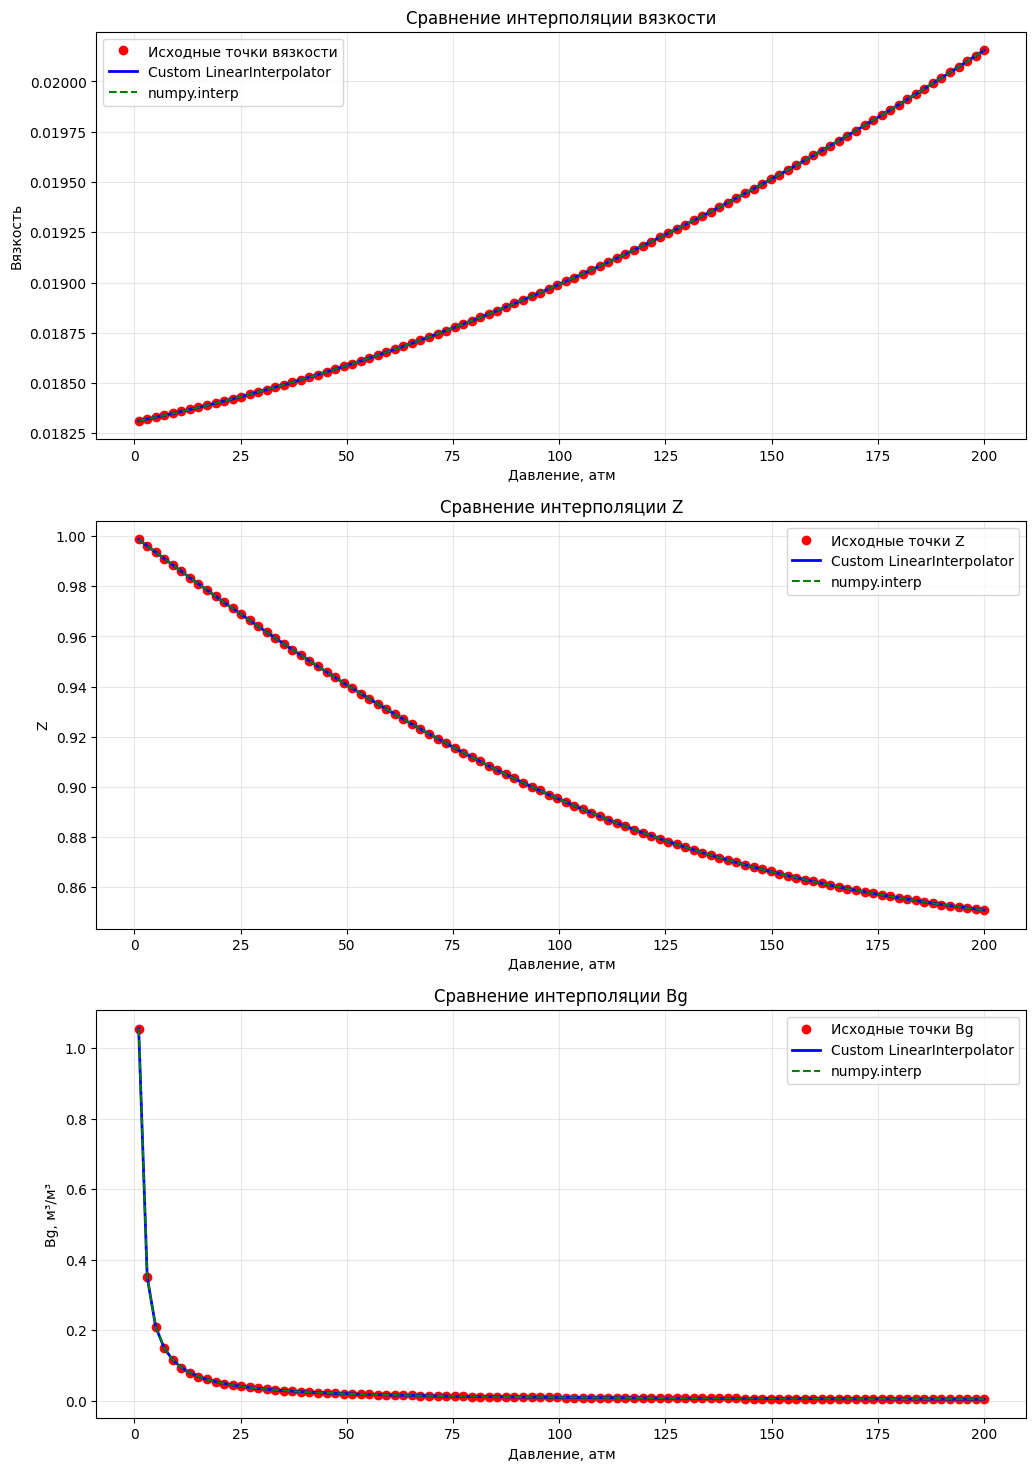

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Извлекаем давлени, вязкость и рассчитанные Z и Bg
P_original = df_pressures['pressure, atm'].tolist()
viscosity_original = df_pressures['viscosity, cP'].tolist()
Z_original = df_pressures['Z'].tolist()
Bg_original = df_pressures['Bg, м³/м³'].tolist()

# Генерируем 500 точек
P_interp = np.linspace(1, 200, 500)

interp_viscosity = LinearInterpolator(P_original, viscosity_original)
interp_Z = LinearInterpolator(P_original, Z_original)
interp_Bg = LinearInterpolator(P_original, Bg_original)

viscosity_custom = [] 
for p in P_interp:
    result = interp_viscosity.predict(p)  
    viscosity_custom.append(result)  
Z_custom = []  
for p in P_interp:
    result = interp_Z.predict(p)
    Z_custom.append(result)
Bg_custom = []  
for p in P_interp:
    result = interp_Bg.predict(p)
    Bg_custom.append(result)

viscosity_numpy = np.interp(P_interp, P_original, viscosity_original)
Z_numpy = np.interp(P_interp, P_original, Z_original)
Bg_numpy = np.interp(P_interp, P_original, Bg_original)

# Строим графики
plt.figure(figsize=(12, 18))

# График вязкости
plt.subplot(3, 1, 1)
plt.plot(P_original, viscosity_original, 'ro', label='Исходные точки вязкости', markersize=6)
plt.plot(P_interp, viscosity_custom, 'b-', label='Custom LinearInterpolator', linewidth=2)
plt.plot(P_interp, viscosity_numpy, 'g--', label='numpy.interp', linewidth=1.5)
plt.xlabel('Давление, атм')
plt.ylabel('Вязкость')
plt.title('Сравнение интерполяции вязкости')
plt.legend()
plt.grid(True, alpha=0.3)


# График Z
plt.subplot(3, 1, 2)
plt.plot(P_original, Z_original, 'ro', label='Исходные точки Z', markersize=6)
plt.plot(P_interp, Z_custom, 'b-', label='Custom LinearInterpolator', linewidth=2)
plt.plot(P_interp, Z_numpy, 'g--', label='numpy.interp', linewidth=1.5)
plt.xlabel('Давление, атм')
plt.ylabel('Z')
plt.title('Сравнение интерполяции Z')
plt.legend()
plt.grid(True, alpha=0.3)


# График Bg
plt.subplot(3, 1, 3)
plt.plot(P_original, Bg_original, 'ro', label='Исходные точки Bg', markersize=6)
plt.plot(P_interp, Bg_custom, 'b-', label='Custom LinearInterpolator', linewidth=2)
plt.plot(P_interp, Bg_numpy, 'g--', label='numpy.interp', linewidth=1.5)
plt.xlabel('Давление, атм')
plt.ylabel('Bg, м³/м³')
plt.title('Сравнение интерполяции Bg')
plt.legend()
plt.grid(True, alpha=0.3)